<a href="https://colab.research.google.com/github/BharathSaiElugam/House-price-predictor3/blob/main/AI_ML_Task3_Model_Validation_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib

# Helper: works whether your sklearn version supports squared=False or not
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## Load & Prepare Dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features:", list(X.columns))
print("Shape:", X.shape)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: (20640, 8)


## Feature Scaling

In [4]:
#scaling is required for fair leraning and stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], " | Test size:", X_test.shape[0])

Train size: 16512  | Test size: 4128


In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [7]:
# Linear Regression baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lr_pred = lin_reg.predict(X_test)
lr_rmse = rmse(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

# Ridge Regression baseline
ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train, y_train)
ridge_pred = ridge_reg.predict(X_test)
ridge_rmse = rmse(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Linear Regression -> RMSE: {lr_rmse:.4f}, R2: {lr_r2:.4f}")
print(f"Ridge Regression  -> RMSE: {ridge_rmse:.4f}, R2: {ridge_r2:.4f}")

Linear Regression -> RMSE: 0.7456, R2: 0.5758
Ridge Regression  -> RMSE: 0.7456, R2: 0.5758


## Detect Overfitting

In [8]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = rmse(y_train, train_pred)
test_rmse = rmse(y_test, test_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"Gap (Test - Train): {test_rmse - train_rmse:.4f}")

Train RMSE: 0.0000
Test RMSE:  0.7030
Gap (Test - Train): 0.7030


In [9]:
#**Interpretation**
# A large gap between training and test RMSE indicates overfitting.
#  This is common in tree-based models without depth/leaf constraints — an unconstrained tree can memorize the training data almost perfectly(train RMSE near 0) while performing much worse on unseen data.

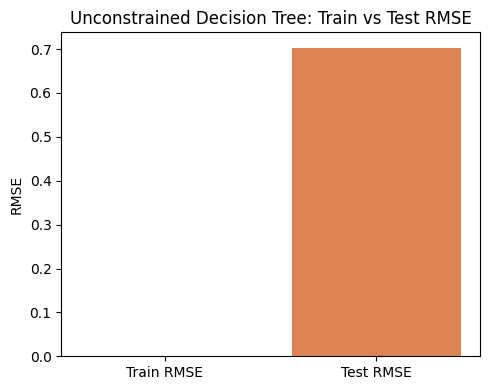

In [10]:
#visualize the overfitting gap
plt.figure(figsize=(5,4))
plt.bar(["Train RMSE", "Test RMSE"], [train_rmse, test_rmse], color=["#4C72B0", "#DD8452"])
plt.title("Unconstrained Decision Tree: Train vs Test RMSE")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150)
plt.show()

## Cross Validation

In [11]:
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()
cv_rmse_std = cv_scores.std()

print("Per-fold RMSE:", -cv_scores)
print(f"Mean CV RMSE: {cv_rmse:.4f} (+/- {cv_rmse_std:.4f})")

Per-fold RMSE: [0.88767617 0.82781619 0.89845112 0.94507041 0.91950207]
Mean CV RMSE: 0.8957 (+/- 0.0392)


In [12]:
# Why Cross-Validation Matters?
# Reduces dependency on one train-test split
# Provides stable and realistic performance estimation
# Used by professionals before deployment

## Hyperparameter Tuning Using GridSearchCV

In [13]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE: 0.6366408923917068


## Evaluate Optimized Model

In [14]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

tuned_rmse = rmse(y_test, y_pred)
tuned_r2 = r2_score(y_test, y_pred)

print(f"Tuned Decision Tree -> RMSE: {tuned_rmse:.4f}, R2: {tuned_r2:.4f}")

# Check the overfitting gap again, post-tuning
tuned_train_pred = best_tree.predict(X_train)
tuned_train_rmse = rmse(y_train, tuned_train_pred)
print(f"Tuned Train RMSE: {tuned_train_rmse:.4f}  | Gap: {tuned_rmse - tuned_train_rmse:.4f}")

Tuned Decision Tree -> RMSE: 0.6454, R2: 0.6821
Tuned Train RMSE: 0.4804  | Gap: 0.1651


## Model Comparison

In [15]:
results = {
    "Model": ["Linear Regression", "Ridge Regression", "Untuned Decision Tree", "Tuned Decision Tree"],
    "Train RMSE": [rmse(y_train, lin_reg.predict(X_train)),
                   rmse(y_train, ridge_reg.predict(X_train)),
                   train_rmse,
                   tuned_train_rmse],
    "Test RMSE": [lr_rmse, ridge_rmse, test_rmse, tuned_rmse],
    "R2 Score": [lr_r2, ridge_r2, r2_score(y_test, test_pred), tuned_r2]
}

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Train RMSE,Test RMSE,R2 Score
0,Linear Regression,7.196757e-01,0.745581,0.575788
1,Ridge Regression,7.196758e-01,0.745554,0.575819
2,Untuned Decision Tree,3.218326e-16,0.703045,0.622811
3,Tuned Decision Tree,4.803530e-01,0.645430,0.682099


In [16]:
comparison_df.to_csv("model_comparison_task3.csv", index=False)
comparison_df

,Model,Train RMSE,Test RMSE,R2 Score
0,Linear Regression,7.196757e-01,0.745581,0.575788
1,Ridge Regression,7.196758e-01,0.745554,0.575819
2,Untuned Decision Tree,3.218326e-16,0.703045,0.622811
3,Tuned Decision Tree,4.803530e-01,0.645430,0.682099


## Save the final trained model

In [17]:
joblib.dump(best_tree, "final_tuned_decision_tree.joblib")
print("Model saved as final_tuned_decision_tree.joblib")

Model saved as final_tuned_decision_tree.joblib
